# Atividade KMeans — Análise de Crédito

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_rows', None)

## 1. Carregamento e exploração dos dados

In [4]:
df = pd.read_csv('../data/credito.csv')
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [5]:
df.shape

(690, 16)

In [6]:
df.describe()

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


## 2. Pré-processamento

In [8]:
# KMeans só trabalha com números, então as colunas de texto precisam virar inteiros.
# .codes transforma cada categoria em um número — 'Energy'=0, 'Financials'=1, etc.
df['Industry_enc']  = pd.Categorical(df['Industry']).codes
df['Ethnicity_enc'] = pd.Categorical(df['Ethnicity']).codes
df['Citizen_enc']   = pd.Categorical(df['Citizen']).codes

# Conjunto completo de features
features_all = [
    'Age', 'Debt', 'Income', 'CreditScore', 'YearsEmployed', 'ZipCode',
    'Married', 'BankCustomer', 'Employed', 'PriorDefault',
    'Industry_enc', 'Ethnicity_enc', 'Citizen_enc'
]

# Conjunto reduzido: apenas variáveis financeiras
features_fin = ['Age', 'Debt', 'Income', 'CreditScore', 'YearsEmployed']

scaler = StandardScaler()
X_all = scaler.fit_transform(df[features_all])

scaler_fin = StandardScaler()
X_fin = scaler_fin.fit_transform(df[features_fin])

## 3. Método do Cotovelo

Rodamos o KMeans para k de 2 a 10 e comparamos duas configurações de features: todas as variáveis disponíveis e só as financeiras. A ideia é ver onde a curva de inércia para de cair com força.

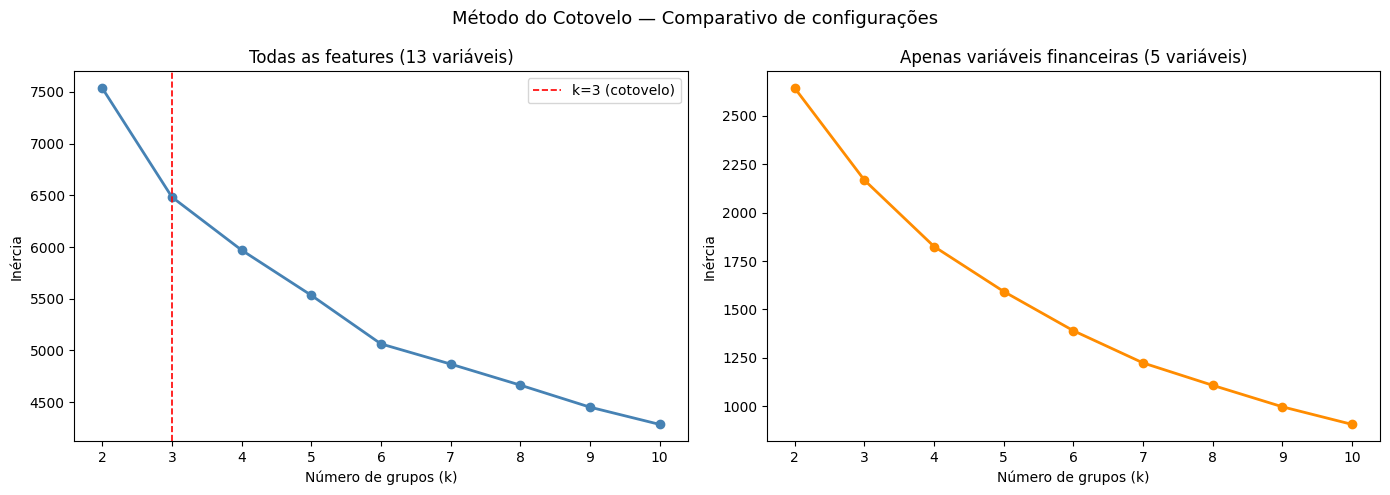

In [9]:
k_range = range(2, 11)
inercias_all = []
inercias_fin = []

for k in k_range:
    km_a = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_a.fit(X_all)
    inercias_all.append(km_a.inertia_)

    km_f = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_f.fit(X_fin)
    inercias_fin.append(km_f.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inercias_all, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (cotovelo)')
axes[0].set_title('Todas as features (13 variáveis)')
axes[0].set_xlabel('Número de grupos (k)')
axes[0].set_ylabel('Inércia')
axes[0].legend()

axes[1].plot(k_range, inercias_fin, marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Apenas variáveis financeiras (5 variáveis)')
axes[1].set_xlabel('Número de grupos (k)')
axes[1].set_ylabel('Inércia')

plt.suptitle('Método do Cotovelo — Comparativo de configurações', fontsize=13)
plt.tight_layout()
plt.show()

# Com todas as features o cotovelo aparece em k=3.
# Com só as financeiras a curva não tem ponto claro — outliers de renda dominam
# a separação e um dos grupos acaba com apenas 4 clientes.

## 4. Treinamento com k=3

In [12]:
# n_init=20 faz o algoritmo tentar 20 pontos de partida diferentes e fica com o melhor.
# Sem isso o KMeans pode travar num resultado ruim dependendo de onde os centroides iniciam.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans.fit(X_all)

df['Cluster'] = kmeans.labels_

print('Quantidade de clientes por grupo:')
print(df['Cluster'].value_counts().sort_index())

Quantidade de clientes por grupo:
Cluster
0    315
1    215
2    160
Name: count, dtype: int64


## 5. Visualização dos grupos — PCA

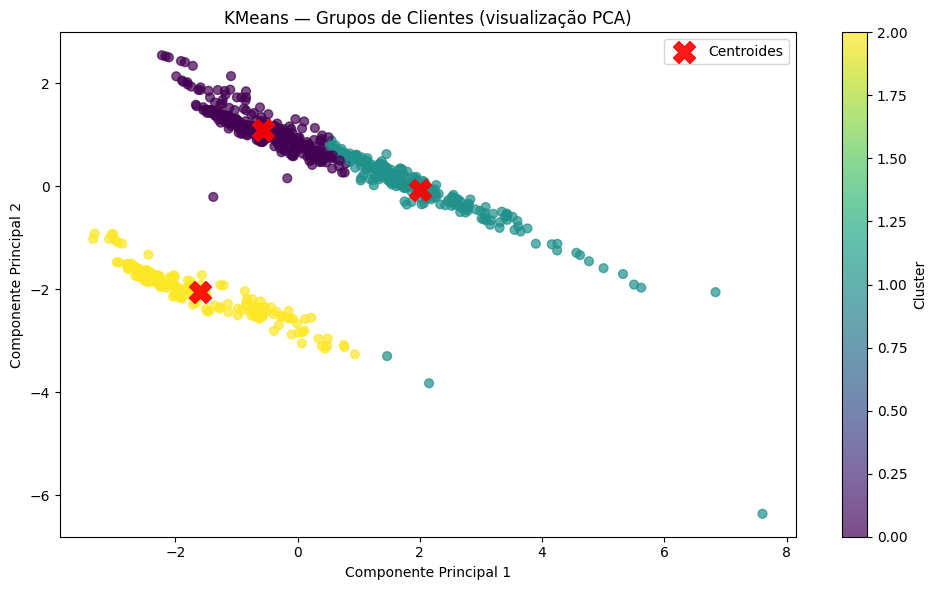

In [11]:
# Com 13 features não dá pra plotar diretamente.
# O PCA comprime tudo em 2 dimensões pra gente conseguir ver os grupos num gráfico.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans.labels_, s=40, cmap='viridis', alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', s=250, alpha=0.9, marker='X', label='Centroides')
plt.colorbar(scatter, label='Cluster')
plt.title('KMeans — Grupos de Clientes (visualização PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Renda média por grupo

Renda média por grupo:
Cluster
0     653.72
1    1959.00
2     468.06
Name: Income, dtype: float64


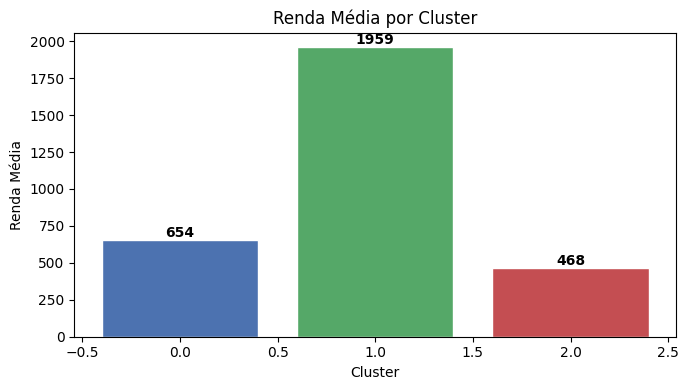

In [13]:
renda_media = df.groupby('Cluster')['Income'].mean().round(2)
print('Renda média por grupo:')
print(renda_media)

plt.figure(figsize=(7, 4))
plt.bar(renda_media.index, renda_media.values,
        color=['#4C72B0','#55A868','#C44E52'], edgecolor='white')
plt.title('Renda Média por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Renda Média')
for i, v in enumerate(renda_media.values):
    plt.text(i, v + 20, f'{v:.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Características de cada grupo

In [14]:
# Médias das variáveis numéricas por cluster
resumo = df.groupby('Cluster')[['Age','Debt','Income','CreditScore','YearsEmployed']].mean().round(2)
resumo

,Age,Debt,Income,CreditScore,YearsEmployed
Cluster,,,,,
0,29.38,3.61,653.72,0.35,1.06
1,36.45,7.11,1959.00,6.46,4.41
2,29.08,3.85,468.06,0.98,1.57


In [15]:
# Taxa de emprego, bom histórico de pagamento e aprovação de crédito por grupo
comportamento = df.groupby('Cluster')[['Employed','PriorDefault','Approved']].mean().round(3) * 100
comportamento.columns = ['Empregados (%)', 'Bom histórico (%)', 'Aprovados (%)']
comportamento

,Empregados (%),Bom histórico (%),Aprovados (%)
Cluster,,,
0,17.5,28.6,23.5
1,92.1,97.2,88.8
2,26.2,38.8,26.2


In [16]:
# Categoria mais comum em cada grupo para as variáveis que não viraram número
for col in ['Industry', 'Ethnicity', 'Citizen']:
    moda = df.groupby('Cluster')[col].agg(lambda x: x.value_counts().index[0])
    print(f'{col} mais frequente por cluster:')
    print(moda)
    print()

Industry mais frequente por cluster:
Cluster
0       Energy
1    Materials
2       Energy
Name: Industry, dtype: object

Ethnicity mais frequente por cluster:
Cluster
0    White
1    White
2    White
Name: Ethnicity, dtype: object

Citizen mais frequente por cluster:
Cluster
0    ByBirth
1    ByBirth
2    ByBirth
Name: Citizen, dtype: object



## 8. Gráficos comparativos

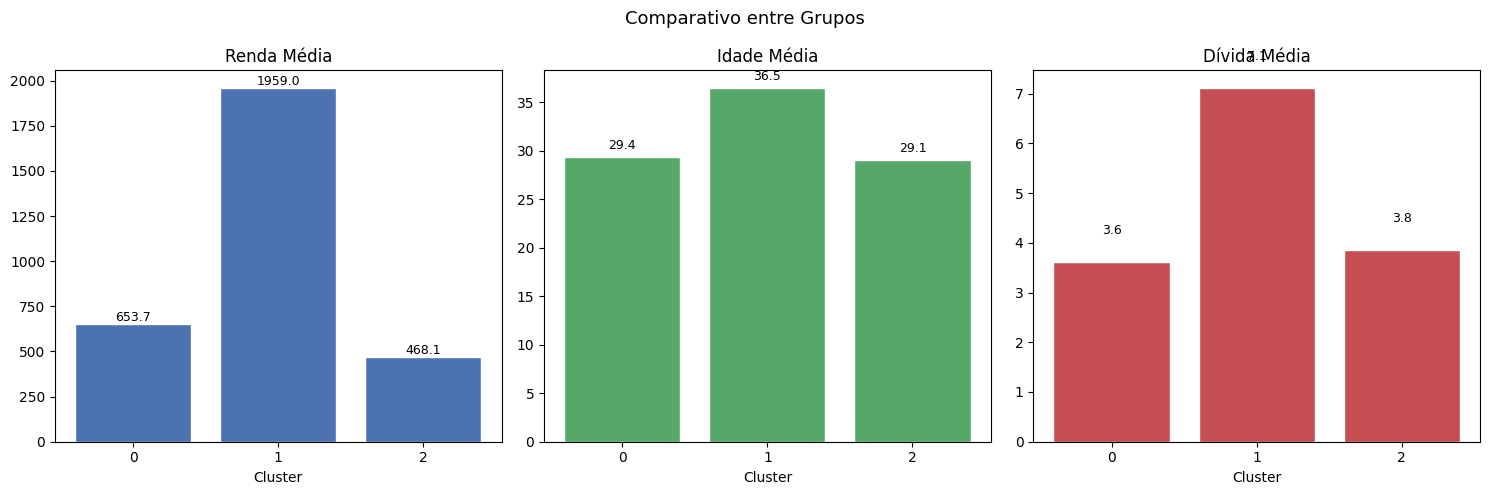

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = ['Income', 'Age', 'Debt']
titulos  = ['Renda Média', 'Idade Média', 'Dívida Média']
cores    = ['#4C72B0', '#55A868', '#C44E52']

for ax, metrica, titulo, cor in zip(axes, metricas, titulos, cores):
    valores = df.groupby('Cluster')[metrica].mean()
    bars = ax.bar(valores.index, valores.values, color=cor, edgecolor='white')
    ax.set_title(titulo)
    ax.set_xlabel('Cluster')
    ax.set_xticks([0, 1, 2])
    for bar, val in zip(bars, valores.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparativo entre Grupos', fontsize=13)
plt.tight_layout()
plt.show()

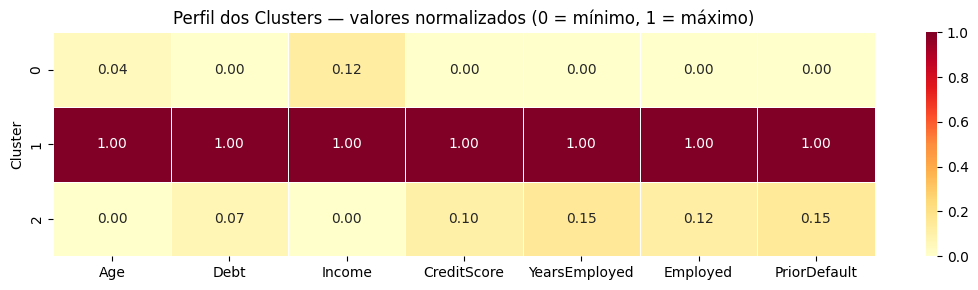

In [20]:
# Heatmap com os valores normalizados — facilita comparar métricas de escalas diferentes
heatmap_data = df.groupby('Cluster')[['Age','Debt','Income','CreditScore','YearsEmployed','Employed','PriorDefault']].mean()
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(11, 3))
sns.heatmap(heatmap_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Perfil dos Clusters — valores normalizados (0 = mínimo, 1 = máximo)')
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

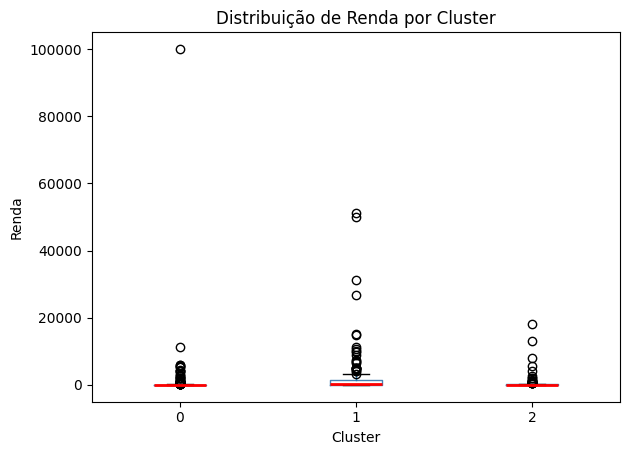

In [21]:
# Boxplot mostra não só a média mas a dispersão da renda dentro de cada grupo
plt.figure(figsize=(9, 5))
df.boxplot(column='Income', by='Cluster', grid=False,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
plt.title('Distribuição de Renda por Cluster')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel('Renda')
plt.tight_layout()
plt.show()

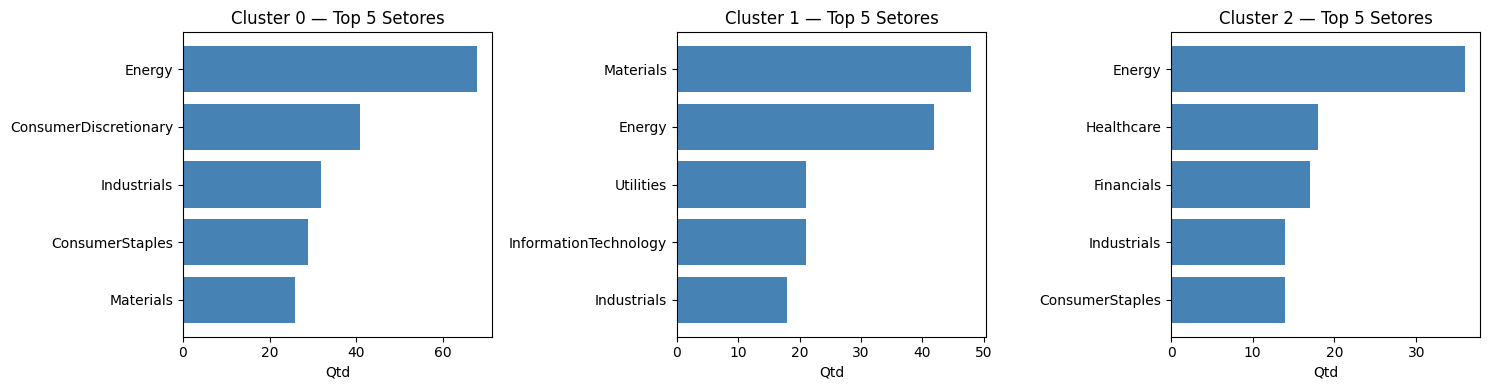

In [22]:
# Top 5 setores por cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    contagem = df[df['Cluster'] == i]['Industry'].value_counts().head(5)
    axes[i].barh(contagem.index, contagem.values, color='steelblue')
    axes[i].set_title(f'Cluster {i} — Top 5 Setores')
    axes[i].set_xlabel('Qtd')
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()